# Unified Memory Core for AI Agents with Oracle AI Database


This notebook implements a practical, Oracle-first memory architecture for AI agents that combines:

- episodic memory as JSON events
- durable relational state
- lexical retrieval with Oracle Text
- tenant-aware access patterns
- lifecycle automation patterns


## What You Will Learn

By the end of this notebook, you will know how to:

1. Connect to Oracle AI Database from Python
2. Model episodic memory as JSON documents
3. Query memory with `JSON_VALUE` and `JSON_TABLE`
4. Build lexical retrieval with Oracle Text (`CONTAINS`) and a fallback path
5. Add semantic vectors and run `VECTOR_DISTANCE` retrieval
6. Combine lexical + vector signals for hybrid search
7. Combine episodic + knowledge retrieval in a unified flow
8. Apply tenant-aware filtering patterns for governed recall
9. Run a graph traversal example with `GRAPH_TABLE`
10. Understand lifecycle automation with `DBMS_SCHEDULER`
11. Prepare Oracle-backed content for framework layers such as LangChain


## Prerequisites

- Python 3.10+
- Access to Oracle AI Database (26ai or compatible environment)
- A database user with privileges for tables, indexes, DML, and queries
- Optional Oracle Text privileges for `CTXSYS.CONTEXT` indexes
- Optional AI Vector Search support (`VECTOR` / `TO_VECTOR` / `VECTOR_DISTANCE`)
- Optional SQL Property Graph privileges for `CREATE PROPERTY GRAPH` and `GRAPH_TABLE`

### Python packages

Required:
- `oracledb`
- `python-dotenv`
- `pandas`

Optional:
- `langchain-core` (only for the final interoperability section)


In [1]:
# Install dependencies (safe to re-run)
# This cell is resilient: it will not stop the notebook if pip has network/proxy restrictions.
import subprocess
import sys

packages = [
    "oracledb",
    "python-dotenv",
    "pandas",
    "matplotlib",
    "langchain-core",
]

failed = []
for pkg in packages:
    cmd = [sys.executable, "-m", "pip", "install", "-q", pkg]
    try:
        subprocess.run(cmd, check=True)
        print(f"OK: {pkg}")
    except Exception:
        failed.append(pkg)
        print(f"WARN: could not install {pkg}. Continuing...")

if failed:
    print("\nSome installs failed (often due network/proxy restrictions).")
    print("Failed packages:", ", ".join(failed))
    print("Notebook can continue for core SQL sections.")
else:
    print("All dependencies installed.")


OK: oracledb
OK: python-dotenv
OK: pandas
OK: matplotlib
OK: langchain-core
All dependencies installed.


## Configuration

Create a `.env` file in the same directory as this notebook:

```bash
ORACLE_USER=app_user
ORACLE_PASSWORD=your_password
ORACLE_DSN=127.0.0.1:1521/FREEPDB1
```

This notebook uses `python-oracledb` in thin mode and keeps the workflow database-native.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

ORACLE_USER = os.getenv("ORACLE_USER")
ORACLE_PASSWORD = os.getenv("ORACLE_PASSWORD")
ORACLE_DSN = os.getenv("ORACLE_DSN")

assert ORACLE_USER and ORACLE_PASSWORD and ORACLE_DSN, (
    "Set ORACLE_USER, ORACLE_PASSWORD, and ORACLE_DSN in your .env file."
)

print(f"User: {ORACLE_USER}")
print(f"DSN:  {ORACLE_DSN}")


User: testuser
DSN:  localhost:1522/FREEPDB1


## Step 1 - Connect to Oracle AI Database

This step establishes a single database connection that the rest of the notebook reuses.

Why this matters for a unified memory core:

- all memory interactions happen in one governed platform
- retrieval and persistence use the same transactional system
- we avoid stitching together disconnected stores for each memory type

Expected output: a successful connection message with the Oracle version.


In [3]:
import oracledb

conn = oracledb.connect(
    user=ORACLE_USER,
    password=ORACLE_PASSWORD,
    dsn=ORACLE_DSN,
)

print(f"Connected to Oracle AI Database")


Connected to Oracle AI Database


## Helper Utilities

`run_sql` executes SQL and optionally returns a Pandas DataFrame.
`lob_to_text` converts Oracle LOB values to plain strings when needed.


In [4]:
import pandas as pd


def lob_to_text(value):
    if hasattr(value, "read"):
        return value.read()
    return value


def run_sql(sql, params=None, fetch=False, many=False, data=None):
    with conn.cursor() as cur:
        if many and data is not None:
            cur.executemany(sql, data)
        else:
            cur.execute(sql, params or {})

        if fetch:
            rows = cur.fetchall()
            cols = [c[0] for c in cur.description]
            return pd.DataFrame(rows, columns=cols)

        conn.commit()


## Step 2 - Create Episodic Memory Table (`agent_events`)

Episodic memory stores events such as user messages, tool calls, tool outputs, checkpoints, and summaries.


In [5]:
run_sql("""
BEGIN
    EXECUTE IMMEDIATE 'DROP TABLE agent_events PURGE';
EXCEPTION
    WHEN OTHERS THEN
        IF SQLCODE != -942 THEN RAISE; END IF;
END;
""")

run_sql("""
CREATE TABLE agent_events (
    event_id    NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
    tenant_id   VARCHAR2(50) NOT NULL,
    session_id  VARCHAR2(100) NOT NULL,
    event_data  JSON NOT NULL,
    created_at  TIMESTAMP DEFAULT SYSTIMESTAMP
)
""")

print("Created table: agent_events")


Created table: agent_events


## Step 3 - Insert Sample Episodic Events

We load a compact but realistic event stream for two tenants.

The dataset intentionally includes mixed event types (`user_message`, `tool_call`, `tool_result`, `checkpoint`, `summary`) so that later SQL/JSON queries demonstrate how memory evolves through an agent workflow.

Expected output: a table with event IDs, tenant IDs, session IDs, and extracted event types.


In [6]:
sample_events = [
    # TENANT_A / session_001
    ("TENANT_A", "session_001", """{"type":"user_message","userId":"user_101","text":"I need help understanding the premium support SLA.","topic":"support_policy"}"""),
    ("TENANT_A", "session_001", """{"type":"tool_call","tool":{"name":"knowledge_lookup","latencyMs":42},"query":"premium support SLA"}"""),
    ("TENANT_A", "session_001", """{"type":"tool_result","tool":{"name":"knowledge_lookup","latencyMs":42},"resultCount":2,"topDocument":"Premium Support SLA Policy"}"""),
    ("TENANT_A", "session_001", """{"type":"checkpoint","status":"context_retrieved","step":"knowledge_retrieval_complete"}"""),
    ("TENANT_A", "session_001", """{"type":"summary","summaryText":"User asked about premium support SLA and policy docs were retrieved.","importance":"high"}"""),

    # TENANT_A / session_002
    ("TENANT_A", "session_002", """{"type":"user_message","userId":"user_101","text":"How do we troubleshoot database performance issues?","topic":"database"}"""),
    ("TENANT_A", "session_002", """{"type":"tool_call","tool":{"name":"knowledge_lookup","latencyMs":58},"query":"database performance troubleshooting"}"""),
    ("TENANT_A", "session_002", """{"type":"tool_result","tool":{"name":"knowledge_lookup","latencyMs":58},"resultCount":1,"topDocument":"Database Performance Troubleshooting Guide"}"""),

    # TENANT_B / session_900
    ("TENANT_B", "session_900", """{"type":"user_message","userId":"user_202","text":"Show me the password reset rules for admin users.","topic":"identity_policy"}"""),
    ("TENANT_B", "session_900", """{"type":"tool_call","tool":{"name":"knowledge_lookup","latencyMs":33},"query":"password reset admin"}"""),
    ("TENANT_B", "session_900", """{"type":"tool_result","tool":{"name":"knowledge_lookup","latencyMs":33},"resultCount":1,"topDocument":"Password Reset Procedure for Admin Users"}"""),
    ("TENANT_B", "session_900", """{"type":"checkpoint","status":"ready_to_answer","step":"identity_policy_context_ready"}"""),
    ("TENANT_B", "session_900", """{"type":"summary","summaryText":"Admin reset policy was retrieved and prepared for response.","importance":"medium"}"""),
    ("TENANT_B", "session_901", """{"type":"user_message","userId":"user_202","text":"What does premium support include for my tenant?","topic":"support_policy"}""")
]

run_sql(
    "INSERT INTO agent_events (tenant_id, session_id, event_data) VALUES (:1, :2, :3)",
    many=True,
    data=sample_events,
)
print("Inserted sample episodic events.")


Inserted sample episodic events.


In [7]:
df_events = run_sql("""
SELECT event_id,
       tenant_id,
       session_id,
       JSON_VALUE(event_data, '$.type') AS event_type,
       created_at
FROM agent_events
ORDER BY event_id
""", fetch=True)

df_events


,EVENT_ID,TENANT_ID,SESSION_ID,EVENT_TYPE,CREATED_AT
0,1,TENANT_A,session_001,user_message,2026-04-19 17:38:26.849527
1,2,TENANT_A,session_001,tool_call,2026-04-19 17:38:26.849527
2,3,TENANT_A,session_001,tool_result,2026-04-19 17:38:26.849527
3,4,TENANT_A,session_001,checkpoint,2026-04-19 17:38:26.849527
4,5,TENANT_A,session_001,summary,2026-04-19 17:38:26.849527
5,6,TENANT_A,session_002,user_message,2026-04-19 17:38:26.849527
6,7,TENANT_A,session_002,tool_call,2026-04-19 17:38:26.849527
7,8,TENANT_A,session_002,tool_result,2026-04-19 17:38:26.849527
8,9,TENANT_B,session_900,user_message,2026-04-19 17:38:26.849527
9,10,TENANT_B,session_900,tool_call,2026-04-19 17:38:26.849527


### Event Snapshot Summary

This compact summary is useful in demos and reviews because it validates that event ingestion worked as expected before deeper queries.


## Step 4 - Query Episodic Memory with SQL/JSON

This section shows two query modes that map directly to production agent memory operations:

- `JSON_VALUE` for fast field-level filtering (for example, get all `user_message` events)
- `JSON_TABLE` for projecting nested JSON attributes into relational columns for analytics

Together, they let teams evolve schema gradually without losing queryability.


In [8]:
event_snapshot = (
    df_events
    .groupby(["TENANT_ID", "EVENT_TYPE"], as_index=False)
    .agg(event_count=("EVENT_ID", "count"))
    .sort_values(["TENANT_ID", "event_count"], ascending=[True, False])
)

event_snapshot


,TENANT_ID,EVENT_TYPE,event_count
2,TENANT_A,tool_call,2
3,TENANT_A,tool_result,2
4,TENANT_A,user_message,2
0,TENANT_A,checkpoint,1
1,TENANT_A,summary,1
9,TENANT_B,user_message,2
5,TENANT_B,checkpoint,1
6,TENANT_B,summary,1
7,TENANT_B,tool_call,1
8,TENANT_B,tool_result,1


In [9]:
df_user_messages = run_sql("""
SELECT event_id,
       tenant_id,
       session_id,
       JSON_VALUE(event_data, '$.type')  AS event_type,
       JSON_VALUE(event_data, '$.topic') AS topic,
       JSON_VALUE(event_data, '$.text')  AS text
FROM agent_events
WHERE JSON_VALUE(event_data, '$.type') = 'user_message'
ORDER BY event_id
""", fetch=True)

df_user_messages


,EVENT_ID,TENANT_ID,SESSION_ID,EVENT_TYPE,TOPIC,TEXT
0,1,TENANT_A,session_001,user_message,support_policy,I need help understanding the premium support ...
1,6,TENANT_A,session_002,user_message,database,How do we troubleshoot database performance is...
2,9,TENANT_B,session_900,user_message,identity_policy,Show me the password reset rules for admin users.
3,14,TENANT_B,session_901,user_message,support_policy,What does premium support include for my tenant?


### 4.2 Structured extraction with `JSON_TABLE`

`JSON_TABLE` projects JSON fields into relational columns for analytics and operational monitoring.


In [10]:
df_tool_calls = run_sql("""
SELECT e.event_id,
       e.tenant_id,
       e.session_id,
       jt.tool_name,
       jt.latency_ms,
       jt.query_text
FROM agent_events e,
     JSON_TABLE(
       e.event_data, '$'
       COLUMNS (
         tool_name  VARCHAR2(100) PATH '$.tool.name',
         latency_ms NUMBER        PATH '$.tool.latencyMs',
         query_text VARCHAR2(1000) PATH '$.query'
       )
     ) jt
WHERE JSON_VALUE(e.event_data, '$.type') = 'tool_call'
ORDER BY e.event_id
""", fetch=True)

df_tool_calls


,EVENT_ID,TENANT_ID,SESSION_ID,TOOL_NAME,LATENCY_MS,QUERY_TEXT
0,2,TENANT_A,session_001,knowledge_lookup,42,premium support SLA
1,7,TENANT_A,session_002,knowledge_lookup,58,database performance troubleshooting
2,10,TENANT_B,session_900,knowledge_lookup,33,password reset admin


### Tool Latency Quick View

Even in a toy dataset, this pattern shows how episodic JSON can support operational metrics (for example: tool latency dashboards) without redesigning table schema.


## Step 5 - Tenant-Aware Retrieval Pattern

This query demonstrates explicit tenant filtering at retrieval time.


In [11]:
tool_latency_stats = (
    df_tool_calls
    .groupby("TOOL_NAME", as_index=False)
    .agg(
        calls=("TOOL_NAME", "count"),
        avg_latency_ms=("LATENCY_MS", "mean"),
        max_latency_ms=("LATENCY_MS", "max"),
    )
)

tool_latency_stats["avg_latency_ms"] = tool_latency_stats["avg_latency_ms"].round(2)
tool_latency_stats


,TOOL_NAME,calls,avg_latency_ms,max_latency_ms
0,knowledge_lookup,3,44.33,58


In [12]:
tenant_id = "TENANT_A"

df_tenant_events = run_sql("""
SELECT event_id,
       tenant_id,
       session_id,
       JSON_VALUE(event_data, '$.type') AS event_type,
       CASE
         WHEN JSON_VALUE(event_data, '$.type') = 'summary'
         THEN JSON_VALUE(event_data, '$.summaryText')
         ELSE '[not a summary event]'
       END AS summary_text,
       created_at
FROM agent_events
WHERE tenant_id = :tenant_id
ORDER BY event_id
""", params={"tenant_id": tenant_id}, fetch=True)

df_tenant_events


,EVENT_ID,TENANT_ID,SESSION_ID,EVENT_TYPE,SUMMARY_TEXT,CREATED_AT
0,1,TENANT_A,session_001,user_message,[not a summary event],2026-04-19 17:38:26.849527
1,2,TENANT_A,session_001,tool_call,[not a summary event],2026-04-19 17:38:26.849527
2,3,TENANT_A,session_001,tool_result,[not a summary event],2026-04-19 17:38:26.849527
3,4,TENANT_A,session_001,checkpoint,[not a summary event],2026-04-19 17:38:26.849527
4,5,TENANT_A,session_001,summary,User asked about premium support SLA and polic...,2026-04-19 17:38:26.849527
5,6,TENANT_A,session_002,user_message,[not a summary event],2026-04-19 17:38:26.849527
6,7,TENANT_A,session_002,tool_call,[not a summary event],2026-04-19 17:38:26.849527
7,8,TENANT_A,session_002,tool_result,[not a summary event],2026-04-19 17:38:26.849527


### Why `summary_text` can be empty in raw event logs

In mixed episodic memory, only events with `event_type = 'summary'` carry a summary payload.
For other event types, missing `summaryText` is expected.

To make the output easier to read, the previous table now uses `[not a summary event]`.
The next table shows only true summary events.


In [13]:
df_summary_events = run_sql("""
SELECT event_id,
       tenant_id,
       session_id,
       JSON_VALUE(event_data, '$.summaryText') AS summary_text,
       JSON_VALUE(event_data, '$.importance')  AS importance,
       created_at
FROM agent_events
WHERE tenant_id = :tenant_id
  AND JSON_VALUE(event_data, '$.type') = 'summary'
ORDER BY event_id
""", params={"tenant_id": tenant_id}, fetch=True)

df_summary_events


,EVENT_ID,TENANT_ID,SESSION_ID,SUMMARY_TEXT,IMPORTANCE,CREATED_AT
0,5,TENANT_A,session_001,User asked about premium support SLA and polic...,high,2026-04-19 17:38:26.849527


## Step 5b - Memory Analytics with Pandas

Before moving to knowledge retrieval, we can inspect how memory is distributed.
These tables and charts make it easier to validate that the memory layer is capturing meaningful operational signals.


In [14]:
df_event_mix = run_sql("""
SELECT tenant_id,
       JSON_VALUE(event_data, '$.type') AS event_type,
       COUNT(*) AS event_count
FROM agent_events
GROUP BY tenant_id, JSON_VALUE(event_data, '$.type')
ORDER BY tenant_id, event_type
""", fetch=True)

pivot_event_mix = (
    df_event_mix
    .pivot(index="EVENT_TYPE", columns="TENANT_ID", values="EVENT_COUNT")
    .fillna(0)
    .astype(int)
)

pivot_event_mix



TENANT_ID,TENANT_A,TENANT_B
EVENT_TYPE,,
checkpoint,1,1
summary,1,1
tool_call,2,1
tool_result,2,1
user_message,2,2


In [15]:
# Compact analytics view
print("Event counts by tenant")
display(pivot_event_mix)

pct_by_tenant = (pivot_event_mix / pivot_event_mix.sum(axis=0)).fillna(0) * 100
pct_by_tenant = pct_by_tenant.round(1)
print("\nEvent mix (%) by tenant")
display(pct_by_tenant)


Event counts by tenant


TENANT_ID,TENANT_A,TENANT_B
EVENT_TYPE,,
checkpoint,1,1
summary,1,1
tool_call,2,1
tool_result,2,1
user_message,2,2



Event mix (%) by tenant


TENANT_ID,TENANT_A,TENANT_B
EVENT_TYPE,,
checkpoint,12.5,16.7
summary,12.5,16.7
tool_call,25.0,16.7
tool_result,25.0,16.7
user_message,25.0,33.3


### Event Mix Charts (Matplotlib)

If `matplotlib` is available, this renders a stacked bar chart and a heatmap for tenant/event distribution.


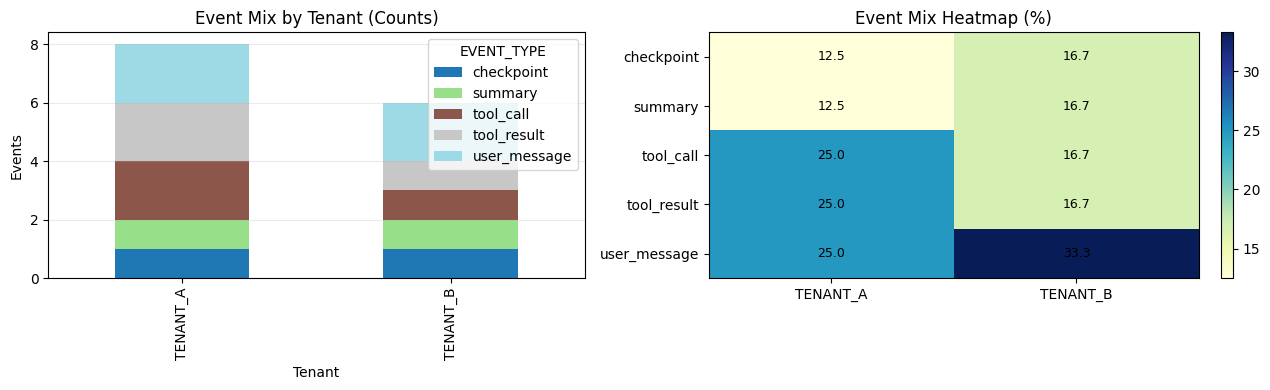

In [16]:
try:
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Stacked bar (absolute counts)
    pivot_event_mix.T.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab20")
    axes[0].set_title("Event Mix by Tenant (Counts)")
    axes[0].set_xlabel("Tenant")
    axes[0].set_ylabel("Events")
    axes[0].grid(axis="y", alpha=0.25)

    # Heatmap (percentage)
    heat = axes[1].imshow(pct_by_tenant.values, aspect="auto", cmap="YlGnBu")
    axes[1].set_title("Event Mix Heatmap (%)")
    axes[1].set_xticks(np.arange(len(pct_by_tenant.columns)))
    axes[1].set_xticklabels(pct_by_tenant.columns)
    axes[1].set_yticks(np.arange(len(pct_by_tenant.index)))
    axes[1].set_yticklabels(pct_by_tenant.index)

    for r in range(pct_by_tenant.shape[0]):
        for c in range(pct_by_tenant.shape[1]):
            axes[1].text(c, r, f"{pct_by_tenant.values[r, c]:.1f}", ha="center", va="center", fontsize=9)

    fig.colorbar(heat, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
except Exception:
    print("matplotlib unavailable; charts skipped. Text/Pandas visualizations above are still valid.")


## Step 6 - Create Knowledge Store (`knowledge_articles`)

Episodic memory tells us what happened. Knowledge memory provides reusable domain context.

In this table, we store tenant-scoped policy and support content that can be retrieved by lexical search. This reflects the article's point that enterprise retrieval needs both durable state and searchable knowledge.


In [17]:
run_sql("""
BEGIN
    EXECUTE IMMEDIATE 'DROP TABLE knowledge_articles PURGE';
EXCEPTION
    WHEN OTHERS THEN
        IF SQLCODE != -942 THEN RAISE; END IF;
END;
""")

run_sql("""
CREATE TABLE knowledge_articles (
    article_id   NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
    tenant_id    VARCHAR2(50) NOT NULL,
    title        VARCHAR2(300) NOT NULL,
    category     VARCHAR2(100),
    content      CLOB,
    created_at   TIMESTAMP DEFAULT SYSTIMESTAMP
)
""")

sample_articles = [
    ("TENANT_A", "Premium Support SLA Policy", "support",
     "Premium support requests receive a first response target of 30 minutes for severity 1 incidents. Customers must provide environment details and business impact when opening the ticket."),
    ("TENANT_A", "Password Reset Procedure for Admin Users", "identity",
     "Admin password reset requests require identity verification and a secondary approval step. Emergency resets must be logged for audit review."),
    ("TENANT_A", "Database Performance Troubleshooting Guide", "database",
     "When users report database performance issues, support should review execution plans, workload changes, and resource usage."),
    ("TENANT_B", "Tenant B Premium Support Terms", "support",
     "Tenant B premium support includes 24x7 handling for priority incidents and dedicated escalation workflows.")
]

run_sql(
    "INSERT INTO knowledge_articles (tenant_id, title, category, content) VALUES (:1, :2, :3, :4)",
    many=True,
    data=sample_articles,
)

print("Created and populated: knowledge_articles")


Created and populated: knowledge_articles


In [18]:
df_articles = run_sql("""
SELECT article_id, tenant_id, title, category, created_at
FROM knowledge_articles
ORDER BY article_id
""", fetch=True)

df_articles


,ARTICLE_ID,TENANT_ID,TITLE,CATEGORY,CREATED_AT
0,1,TENANT_A,Premium Support SLA Policy,support,2026-04-19 17:39:10.613809
1,2,TENANT_A,Password Reset Procedure for Admin Users,identity,2026-04-19 17:39:10.613809
2,3,TENANT_A,Database Performance Troubleshooting Guide,database,2026-04-19 17:39:10.613809
3,4,TENANT_B,Tenant B Premium Support Terms,support,2026-04-19 17:39:10.613809


### Knowledge Catalog Coverage

This table gives a quick governance check: how many knowledge items exist per tenant and category.


## Step 7 - Lexical Retrieval with Oracle Text

In enterprise workflows, many queries depend on exact terms (for example: policy names, codes, ticket IDs).
That is why lexical retrieval is part of a unified memory core.

To keep this notebook robust, we create Oracle Text indexes for both `content` and `title`.
If Oracle Text privileges are unavailable, the notebook falls back to a `LIKE`-based search path so the demo still runs.


In [19]:
knowledge_mix = (
    df_articles
    .groupby(["TENANT_ID", "CATEGORY"], as_index=False)
    .agg(article_count=("ARTICLE_ID", "count"))
    .sort_values(["TENANT_ID", "article_count"], ascending=[True, False])
)

knowledge_mix


,TENANT_ID,CATEGORY,article_count
0,TENANT_A,database,1
1,TENANT_A,identity,1
2,TENANT_A,support,1
3,TENANT_B,support,1


In [20]:
oracle_text_enabled = True

try:
    run_sql("""
    BEGIN
        EXECUTE IMMEDIATE 'DROP INDEX knowledge_articles_text_idx';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE NOT IN (-1418, -942) THEN RAISE; END IF;
    END;
    """)

    run_sql("""
    BEGIN
        EXECUTE IMMEDIATE 'DROP INDEX knowledge_articles_title_idx';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE NOT IN (-1418, -942) THEN RAISE; END IF;
    END;
    """)

    run_sql("""
    CREATE INDEX knowledge_articles_text_idx
    ON knowledge_articles(content)
    INDEXTYPE IS CTXSYS.CONTEXT
    """)

    run_sql("""
    CREATE INDEX knowledge_articles_title_idx
    ON knowledge_articles(title)
    INDEXTYPE IS CTXSYS.CONTEXT
    """)

    print("Oracle Text indexes created: knowledge_articles_text_idx, knowledge_articles_title_idx")
except Exception as exc:
    oracle_text_enabled = False
    print("Oracle Text index creation skipped. Falling back to LIKE search.")
    print(f"Reason: {exc}")



Oracle Text indexes created: knowledge_articles_text_idx, knowledge_articles_title_idx


In [21]:
query_text = "premium support SLA"
tenant_id = "TENANT_A"

if oracle_text_enabled:
    df_lexical = run_sql("""
    SELECT article_id,
           tenant_id,
           title,
           GREATEST(NVL(SCORE(1), 0), NVL(SCORE(2), 0)) AS relevance
    FROM knowledge_articles
    WHERE tenant_id = :tenant_id
      AND (
           CONTAINS(content, :query_text, 1) > 0
        OR CONTAINS(title,   :query_text, 2) > 0
      )
    ORDER BY relevance DESC
    FETCH FIRST 10 ROWS ONLY
    """, params={"tenant_id": tenant_id, "query_text": query_text}, fetch=True)
else:
    df_lexical = run_sql("""
    SELECT article_id,
           tenant_id,
           title,
           0 AS relevance
    FROM knowledge_articles
    WHERE tenant_id = :tenant_id
      AND LOWER(title || ' ' || content) LIKE '%' || LOWER(:query_text) || '%'
    ORDER BY article_id
    FETCH FIRST 10 ROWS ONLY
    """, params={"tenant_id": tenant_id, "query_text": query_text}, fetch=True)

df_lexical



,ARTICLE_ID,TENANT_ID,TITLE,RELEVANCE
0,1,TENANT_A,Premium Support SLA Policy,5


### Interpreting Lexical Results

Higher `relevance` indicates a stronger lexical match under Oracle Text scoring.
In production, this ranking is typically combined with semantic and metadata filters.


### Lexical Search Examples (Pandas Table)

The table below runs multiple realistic enterprise queries and shows top matches.


In [22]:
test_queries = [
    "premium support SLA",
    "password reset admin",
    "database performance",
]

rows = []
for q in test_queries:
    if oracle_text_enabled:
        df_q = run_sql("""
        SELECT title,
               GREATEST(NVL(SCORE(1), 0), NVL(SCORE(2), 0)) AS relevance
        FROM knowledge_articles
        WHERE tenant_id = :tenant_id
          AND (
               CONTAINS(content, :q, 1) > 0
            OR CONTAINS(title,   :q, 2) > 0
          )
        ORDER BY relevance DESC
        FETCH FIRST 1 ROWS ONLY
        """, params={"tenant_id": "TENANT_A", "q": q}, fetch=True)
    else:
        df_q = run_sql("""
        SELECT title, 0 AS relevance
        FROM knowledge_articles
        WHERE tenant_id = :tenant_id
          AND LOWER(title || ' ' || content) LIKE '%' || LOWER(:q) || '%'
        ORDER BY article_id
        FETCH FIRST 1 ROWS ONLY
        """, params={"tenant_id": "TENANT_A", "q": q}, fetch=True)

    if len(df_q) == 0:
        rows.append({"query": q, "top_title": "No match", "relevance": 0})
    else:
        rows.append({
            "query": q,
            "top_title": df_q.iloc[0]["TITLE"],
            "relevance": df_q.iloc[0]["RELEVANCE"],
        })

df_lexical_examples = pd.DataFrame(rows)
df_lexical_examples



,query,top_title,relevance
0,premium support SLA,Premium Support SLA Policy,5
1,password reset admin,No match,0
2,database performance,Database Performance Troubleshooting Guide,5


### Step 7b - Add Semantic Vectors to Knowledge Memory

To extend lexical retrieval, we add a vector column and store a lightweight demo embedding for each article.
This enables semantic similarity search, so retrieval can match meaning, not only exact terms.

Expected output: confirmation that `content_vec` was created (or already exists) and vectors were populated.

In [23]:
vector_enabled = True
vector_dim = 8


def demo_embedding_from_text(text: str) -> str:
    # Deterministic lightweight embedding for demo purposes (no external model required).
    text = (text or "").lower()
    vec = [0.0] * vector_dim

    keyword_groups = {
        0: ["support", "sla", "premium", "severity", "incident"],
        1: ["password", "reset", "identity", "admin", "verification", "approval"],
        2: ["database", "performance", "query", "execution", "resource", "workload"],
        3: ["tenant", "isolation", "policy", "security", "governance"],
        4: ["ticket", "case", "escalation", "workflow"],
        5: ["document", "knowledge", "guide", "procedure", "article"],
        6: ["latency", "response", "minutes", "24x7"],
        7: ["audit", "review", "compliance", "log"],
    }

    for idx, words in keyword_groups.items():
        vec[idx] = float(sum(text.count(w) for w in words))

    total = sum(vec)
    if total == 0:
        vec[5] = 1.0
        total = 1.0

    vec = [round(v / total, 6) for v in vec]
    return "[" + ", ".join(f"{v:.6f}" for v in vec) + "]"


try:
    col_exists_df = run_sql("""
    SELECT COUNT(*) AS col_count
    FROM user_tab_cols
    WHERE table_name = 'KNOWLEDGE_ARTICLES'
      AND column_name = 'CONTENT_VEC'
    """, fetch=True)

    col_exists = int(col_exists_df.iloc[0]["COL_COUNT"]) > 0
    if not col_exists:
        run_sql(f"ALTER TABLE knowledge_articles ADD (content_vec VECTOR({vector_dim}, FLOAT32))")

    df_embed_source = run_sql("""
    SELECT article_id, title, content
    FROM knowledge_articles
    ORDER BY article_id
    """, fetch=True)

    embedding_rows = []
    for _, row in df_embed_source.iterrows():
        content_txt = str(lob_to_text(row["CONTENT"])) if row["CONTENT"] is not None else ""
        vector_text = demo_embedding_from_text(f"{row['TITLE']} {content_txt}")
        embedding_rows.append((vector_text, int(row["ARTICLE_ID"])))

    run_sql(
        "UPDATE knowledge_articles SET content_vec = TO_VECTOR(:1) WHERE article_id = :2",
        many=True,
        data=embedding_rows,
    )

    print("Vector column ready and populated: knowledge_articles.content_vec")
except Exception as exc:
    vector_enabled = False
    print("Vector setup skipped; lexical retrieval still works.")
    print(f"Reason: {exc}")


Vector column ready and populated: knowledge_articles.content_vec


### Step 7c - Vector Retrieval with `VECTOR_DISTANCE`

We rank documents by semantic similarity using cosine distance (smaller distance means closer match).

Expected output: top documents sorted by `vector_distance` ascending.


In [24]:
tenant_id = "TENANT_A"
vector_query_text = "premium support SLA with severity 1 response target"
vector_query_vec = demo_embedding_from_text(vector_query_text)

if vector_enabled:
    df_vector = run_sql("""
    SELECT article_id,
           tenant_id,
           title,
           ROUND(VECTOR_DISTANCE(content_vec, TO_VECTOR(:query_vec), COSINE), 6) AS vector_distance
    FROM knowledge_articles
    WHERE tenant_id = :tenant_id
      AND content_vec IS NOT NULL
    ORDER BY vector_distance ASC
    FETCH FIRST 5 ROWS ONLY
    """, params={"tenant_id": tenant_id, "query_vec": vector_query_vec}, fetch=True)
else:
    df_vector = pd.DataFrame([
        {"info": "Vector retrieval skipped in this environment."}
    ])

df_vector


,ARTICLE_ID,TENANT_ID,TITLE,VECTOR_DISTANCE
0,1,TENANT_A,Premium Support SLA Policy,0.018895
1,3,TENANT_A,Database Performance Troubleshooting Guide,0.865465
2,2,TENANT_A,Password Reset Procedure for Admin Users,1.000000


### Step 7d - Hybrid Retrieval (`Oracle Text` + Vector + Metadata)

This combines lexical precision (`CONTAINS`), semantic similarity (`VECTOR_DISTANCE`), and metadata filtering (`tenant_id`, optional `category`) into one ranking score.


In [25]:
hybrid_query_text = "premium support SLA"
hybrid_query_vec = demo_embedding_from_text(hybrid_query_text)
hybrid_category = "support"

if vector_enabled and oracle_text_enabled:
    df_hybrid = run_sql("""
    WITH scored AS (
        SELECT article_id,
               tenant_id,
               title,
               category,
               GREATEST(NVL(SCORE(1), 0), NVL(SCORE(2), 0)) AS lexical_score,
               VECTOR_DISTANCE(content_vec, TO_VECTOR(:query_vec), COSINE) AS vector_distance
        FROM knowledge_articles
        WHERE tenant_id = :tenant_id
          AND category = :category
          AND content_vec IS NOT NULL
          AND (
               CONTAINS(content, :query_text, 1) > 0
            OR CONTAINS(title,   :query_text, 2) > 0
          )
    )
    SELECT article_id,
           tenant_id,
           title,
           category,
           lexical_score,
           ROUND(vector_distance, 6) AS vector_distance,
           ROUND(
               0.45 * LEAST(lexical_score, 100) / 100
               + 0.55 * (1 - vector_distance),
               6
           ) AS hybrid_score
    FROM scored
    ORDER BY hybrid_score DESC
    FETCH FIRST 5 ROWS ONLY
    """, params={
        "tenant_id": "TENANT_A",
        "category": hybrid_category,
        "query_text": hybrid_query_text,
        "query_vec": hybrid_query_vec,
    }, fetch=True)
elif vector_enabled:
    df_hybrid = run_sql("""
    SELECT article_id,
           tenant_id,
           title,
           category,
           0 AS lexical_score,
           ROUND(VECTOR_DISTANCE(content_vec, TO_VECTOR(:query_vec), COSINE), 6) AS vector_distance,
           ROUND(1 - VECTOR_DISTANCE(content_vec, TO_VECTOR(:query_vec), COSINE), 6) AS hybrid_score
    FROM knowledge_articles
    WHERE tenant_id = :tenant_id
      AND category = :category
      AND content_vec IS NOT NULL
    ORDER BY hybrid_score DESC
    FETCH FIRST 5 ROWS ONLY
    """, params={
        "tenant_id": "TENANT_A",
        "category": hybrid_category,
        "query_vec": hybrid_query_vec,
    }, fetch=True)
else:
    df_hybrid = df_lexical.copy()
    if "RELEVANCE" in df_hybrid.columns:
        df_hybrid["HYBRID_SCORE"] = df_hybrid["RELEVANCE"]

df_hybrid


,ARTICLE_ID,TENANT_ID,TITLE,CATEGORY,LEXICAL_SCORE,VECTOR_DISTANCE,HYBRID_SCORE
0,1,TENANT_A,Premium Support SLA Policy,support,5,0.05612,0.541634


## Step 8 - Unified Retrieval Flow (Episodic + Knowledge)

A minimal unified memory flow:

1. Read the latest user event from episodic memory
2. Use that text to retrieve tenant-scoped knowledge
3. Return ranked candidates for grounded response generation

This mirrors the article's design principle: memory recall should combine durable state, governed filtering, and relevant retrieval in one execution path.

Expected output: the latest user message plus a ranked list of candidate knowledge articles.


In [26]:
latest_event = run_sql("""
SELECT tenant_id,
       session_id,
       JSON_VALUE(event_data, '$.text') AS user_text
FROM agent_events
WHERE tenant_id = :tenant_id
  AND session_id = :session_id
  AND JSON_VALUE(event_data, '$.type') = 'user_message'
ORDER BY event_id DESC
FETCH FIRST 1 ROWS ONLY
""", params={"tenant_id": "TENANT_A", "session_id": "session_001"}, fetch=True)

latest_event


,TENANT_ID,SESSION_ID,USER_TEXT
0,TENANT_A,session_001,I need help understanding the premium support ...


In [28]:
user_text = latest_event.iloc[0]["USER_TEXT"]
retrieval_mode = "unknown"
candidates = None

if oracle_text_enabled:
    retrieval_mode = "oracle_text_raw"
    retrieval_sql = """
    SELECT article_id,
           title,
           GREATEST(NVL(SCORE(1), 0), NVL(SCORE(2), 0)) AS relevance
    FROM knowledge_articles
    WHERE tenant_id = :tenant_id
      AND (
           CONTAINS(content, :q, 1) > 0
        OR CONTAINS(title,   :q, 2) > 0
      )
    ORDER BY relevance DESC
    FETCH FIRST 3 ROWS ONLY
    """

    try:
        candidates = run_sql(retrieval_sql, params={"tenant_id": "TENANT_A", "q": user_text}, fetch=True)
    except Exception:
        candidates = None

    if candidates is None or len(candidates) == 0:
        retrieval_mode = "oracle_text_keywords"
        keyword_q = "premium OR support OR sla"
        try:
            candidates = run_sql(retrieval_sql, params={"tenant_id": "TENANT_A", "q": keyword_q}, fetch=True)
        except Exception:
            candidates = None

if candidates is None or len(candidates) == 0:
    retrieval_mode = "like_fallback"
    retrieval_sql = """
    SELECT article_id,
           title,
           0 AS relevance
    FROM knowledge_articles
    WHERE tenant_id = :tenant_id
      AND LOWER(title || ' ' || content) LIKE '%' || LOWER(:q) || '%'
    ORDER BY article_id
    FETCH FIRST 3 ROWS ONLY
    """
    candidates = run_sql(retrieval_sql, params={"tenant_id": "TENANT_A", "q": "premium support"}, fetch=True)

if len(candidates) == 0:
    retrieval_mode = "tenant_topk_fallback"
    candidates = run_sql("""
    SELECT article_id,
           title,
           0.01 AS relevance
    FROM knowledge_articles
    WHERE tenant_id = :tenant_id
    ORDER BY article_id
    FETCH FIRST 3 ROWS ONLY
    """, params={"tenant_id": "TENANT_A"}, fetch=True)

print("Latest user text:", user_text)
print("Retrieval mode:", retrieval_mode)
candidates


Latest user text: I need help understanding the premium support SLA.
Retrieval mode: oracle_text_keywords


,ARTICLE_ID,TITLE,RELEVANCE
0,1,Premium Support SLA Policy,5
1,3,Database Performance Troubleshooting Guide,3


### Retrieval Outcome Summary

This final table packages the unified retrieval outcome into one review-friendly artifact.


In [29]:
top_titles = ", ".join(candidates["TITLE"].tolist()) if len(candidates) else "No candidates"

unified_result = pd.DataFrame([
    {
        "tenant_id": "TENANT_A",
        "session_id": "session_001",
        "retrieval_mode": retrieval_mode,
        "latest_user_text": user_text,
        "top_article": candidates.iloc[0]["TITLE"] if len(candidates) else "No match",
        "top_relevance": float(candidates.iloc[0]["RELEVANCE"]) if len(candidates) else 0.0,
        "candidate_count": int(len(candidates)),
        "candidate_titles": top_titles,
    }
])

unified_result


,tenant_id,session_id,retrieval_mode,latest_user_text,top_article,top_relevance,candidate_count,candidate_titles
0,TENANT_A,session_001,oracle_text_keywords,I need help understanding the premium support ...,Premium Support SLA Policy,5.0,2,"Premium Support SLA Policy, Database Performan..."


### Step 8b - Graph Pattern with `GRAPH_TABLE`

This section demonstrates a `user -> ticket -> document` traversal.
We model the relationships with SQL Property Graph and query connected paths using `GRAPH_TABLE`.


In [30]:
graph_setup_sql = [
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP TABLE graph_user_ticket_edges PURGE';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE != -942 THEN RAISE; END IF;
    END;
    """,
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP TABLE graph_ticket_document_edges PURGE';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE != -942 THEN RAISE; END IF;
    END;
    """,
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP TABLE graph_documents PURGE';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE != -942 THEN RAISE; END IF;
    END;
    """,
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP TABLE graph_tickets PURGE';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE != -942 THEN RAISE; END IF;
    END;
    """,
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP TABLE graph_users PURGE';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE != -942 THEN RAISE; END IF;
    END;
    """,
]

for stmt in graph_setup_sql:
    run_sql(stmt)

run_sql("""
CREATE TABLE graph_users (
    user_id      VARCHAR2(50) PRIMARY KEY,
    tenant_id    VARCHAR2(50) NOT NULL,
    user_name    VARCHAR2(100)
)
""")

run_sql("""
CREATE TABLE graph_tickets (
    ticket_id    VARCHAR2(50) PRIMARY KEY,
    tenant_id    VARCHAR2(50) NOT NULL,
    subject      VARCHAR2(300),
    status       VARCHAR2(30)
)
""")

run_sql("""
CREATE TABLE graph_documents (
    doc_id       VARCHAR2(50) PRIMARY KEY,
    tenant_id    VARCHAR2(50) NOT NULL,
    title        VARCHAR2(300),
    category     VARCHAR2(100)
)
""")

run_sql("""
CREATE TABLE graph_user_ticket_edges (
    edge_id       NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
    tenant_id     VARCHAR2(50) NOT NULL,
    user_id       VARCHAR2(50) NOT NULL,
    ticket_id     VARCHAR2(50) NOT NULL,
    relation_type VARCHAR2(30)
)
""")

run_sql("""
CREATE TABLE graph_ticket_document_edges (
    edge_id       NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
    tenant_id     VARCHAR2(50) NOT NULL,
    ticket_id     VARCHAR2(50) NOT NULL,
    doc_id        VARCHAR2(50) NOT NULL,
    relation_type VARCHAR2(30)
)
""")

run_sql(
    "INSERT INTO graph_users (user_id, tenant_id, user_name) VALUES (:1, :2, :3)",
    many=True,
    data=[
        ("user_101", "TENANT_A", "Alicia"),
        ("user_201", "TENANT_B", "Marcus"),
    ],
)

run_sql(
    "INSERT INTO graph_tickets (ticket_id, tenant_id, subject, status) VALUES (:1, :2, :3, :4)",
    many=True,
    data=[
        ("TCK-1001", "TENANT_A", "Premium SLA clarification", "open"),
        ("TCK-1002", "TENANT_A", "Password reset escalation", "resolved"),
        ("TCK-2001", "TENANT_B", "Tenant B support escalation", "open"),
    ],
)

run_sql(
    "INSERT INTO graph_documents (doc_id, tenant_id, title, category) VALUES (:1, :2, :3, :4)",
    many=True,
    data=[
        ("DOC-501", "TENANT_A", "Premium Support SLA Policy", "support"),
        ("DOC-502", "TENANT_A", "Password Reset Procedure for Admin Users", "identity"),
        ("DOC-601", "TENANT_B", "Tenant B Premium Support Terms", "support"),
    ],
)

run_sql(
    "INSERT INTO graph_user_ticket_edges (tenant_id, user_id, ticket_id, relation_type) VALUES (:1, :2, :3, :4)",
    many=True,
    data=[
        ("TENANT_A", "user_101", "TCK-1001", "opened"),
        ("TENANT_A", "user_101", "TCK-1002", "opened"),
        ("TENANT_B", "user_201", "TCK-2001", "opened"),
    ],
)

run_sql(
    "INSERT INTO graph_ticket_document_edges (tenant_id, ticket_id, doc_id, relation_type) VALUES (:1, :2, :3, :4)",
    many=True,
    data=[
        ("TENANT_A", "TCK-1001", "DOC-501", "references"),
        ("TENANT_A", "TCK-1002", "DOC-502", "references"),
        ("TENANT_B", "TCK-2001", "DOC-601", "references"),
    ],
)

print("Graph demo tables populated.")


Graph demo tables populated.


In [31]:
graph_enabled = True

try:
    run_sql("""
    BEGIN
        EXECUTE IMMEDIATE 'DROP PROPERTY GRAPH memory_graph';
    EXCEPTION
        WHEN OTHERS THEN
            NULL;
    END;
    """)

    run_sql("""
    CREATE PROPERTY GRAPH memory_graph
      VERTEX TABLES (
        graph_users KEY (user_id)
          LABEL user_v
            PROPERTIES (user_id, tenant_id, user_name),
        graph_tickets KEY (ticket_id)
          LABEL ticket_v
            PROPERTIES (ticket_id, tenant_id, subject, status),
        graph_documents KEY (doc_id)
          LABEL document_v
            PROPERTIES (doc_id, tenant_id, title, category)
      )
      EDGE TABLES (
        graph_user_ticket_edges AS opened_e
          SOURCE KEY (user_id) REFERENCES graph_users (user_id)
          DESTINATION KEY (ticket_id) REFERENCES graph_tickets (ticket_id)
          PROPERTIES (tenant_id, relation_type),
        graph_ticket_document_edges AS mentions_e
          SOURCE KEY (ticket_id) REFERENCES graph_tickets (ticket_id)
          DESTINATION KEY (doc_id) REFERENCES graph_documents (doc_id)
          PROPERTIES (tenant_id, relation_type)
      )
    """)

    df_graph_paths = run_sql("""
    SELECT *
    FROM GRAPH_TABLE (memory_graph
      MATCH (u IS user_v)-[r IS opened_e]->(t IS ticket_v)-[m IS mentions_e]->(d IS document_v)
      WHERE u.user_id = :user_id
        AND u.tenant_id = :tenant_id
      COLUMNS (
        u.user_name AS user_name,
        t.subject   AS ticket_title,
        d.title     AS document_title,
        t.ticket_id AS ticket_id,
        d.doc_id    AS document_id
      )
    )
    """, params={"user_id": "user_101", "tenant_id": "TENANT_A"}, fetch=True)

except Exception as exc:
    graph_enabled = False
    print("GRAPH_TABLE path skipped; falling back to relational join.")
    print(f"Reason: {exc}")

    df_graph_paths = run_sql("""
    SELECT u.user_name AS user_name,
           t.subject AS ticket_title,
           d.title AS document_title,
           t.ticket_id AS ticket_id,
           d.doc_id AS document_id
    FROM graph_users u
    JOIN graph_user_ticket_edges ut
      ON ut.user_id = u.user_id
     AND ut.tenant_id = u.tenant_id
    JOIN graph_tickets t
      ON t.ticket_id = ut.ticket_id
     AND t.tenant_id = ut.tenant_id
    JOIN graph_ticket_document_edges td
      ON td.ticket_id = t.ticket_id
     AND td.tenant_id = t.tenant_id
    JOIN graph_documents d
      ON d.doc_id = td.doc_id
     AND d.tenant_id = td.tenant_id
    WHERE u.user_id = :user_id
      AND u.tenant_id = :tenant_id
    ORDER BY t.ticket_id
    """, params={"user_id": "user_101", "tenant_id": "TENANT_A"}, fetch=True)

df_graph_paths


,USER_NAME,TICKET_TITLE,DOCUMENT_TITLE,TICKET_ID,DOCUMENT_ID
0,Alicia,Premium SLA clarification,Premium Support SLA Policy,TCK-1001,DOC-501
1,Alicia,Password reset escalation,Password Reset Procedure for Admin Users,TCK-1002,DOC-502


This mirrors the article's relationship-aware retrieval: follow graph context around memory items, not only semantic neighbors.


## Step 9 - Lifecycle Automation Pattern (`DBMS_SCHEDULER`)

This is the scheduling pattern from the article for summarization and pruning jobs.


In [32]:
scheduler_sql = """
BEGIN
  DBMS_SCHEDULER.CREATE_JOB(
    job_name        => 'SUMMARIZE_AGENT_SESSIONS',
    job_type        => 'PLSQL_BLOCK',
    job_action      => 'BEGIN memory_pkg.summarize_old_sessions(30); END;',
    repeat_interval => 'FREQ=HOURLY;INTERVAL=6',
    enabled         => TRUE,
    auto_drop       => FALSE
  );
END;
/
"""

print(scheduler_sql)



BEGIN
  DBMS_SCHEDULER.CREATE_JOB(
    job_name        => 'SUMMARIZE_AGENT_SESSIONS',
    job_type        => 'PLSQL_BLOCK',
    job_action      => 'BEGIN memory_pkg.summarize_old_sessions(30); END;',
    repeat_interval => 'FREQ=HOURLY;INTERVAL=6',
    enabled         => TRUE,
    auto_drop       => FALSE
  );
END;
/



## Step 10 - Security Pattern (`DBMS_RLS` / VPD)

Tenant-aware row-level security can be enforced in the database kernel with VPD.


In [33]:
vpd_sql = """
BEGIN
  DBMS_RLS.ADD_POLICY(
    object_schema   => 'APP',
    object_name     => 'AGENT_EVENTS',
    policy_name     => 'TENANT_ISOLATION',
    function_schema => 'APP',
    policy_function => 'TENANT_ISOLATION_POLICY',
    statement_types => 'SELECT, INSERT, UPDATE, DELETE',
    update_check    => TRUE
  );
END;
/
"""

print(vpd_sql)



BEGIN
  DBMS_RLS.ADD_POLICY(
    object_schema   => 'APP',
    object_name     => 'AGENT_EVENTS',
    policy_name     => 'TENANT_ISOLATION',
    function_schema => 'APP',
    policy_function => 'TENANT_ISOLATION_POLICY',
    statement_types => 'SELECT, INSERT, UPDATE, DELETE',
    update_check    => TRUE
  );
END;
/



## LangChain Interoperability

Prepare Oracle-backed rows as LangChain `Document` objects.
The LOB-to-string conversion avoids the `ValidationError` seen when `CLOB` is passed directly.


In [34]:
# LangChain interoperability setup
# If langchain-core is unavailable, we use a tiny fallback document class so the demo still works.
try:
    from langchain_core.documents import Document
    LANGCHAIN_CORE_AVAILABLE = True
except Exception:
    LANGCHAIN_CORE_AVAILABLE = False

    class Document:
        def __init__(self, page_content: str, metadata: dict):
            self.page_content = page_content
            self.metadata = metadata


df_langchain = run_sql("""
SELECT title, content
FROM knowledge_articles
WHERE tenant_id = 'TENANT_A'
ORDER BY article_id
""", fetch=True)

docs = []
for _, row in df_langchain.iterrows():
    content = lob_to_text(row["CONTENT"])
    docs.append(
        Document(
            page_content=str(content) if content is not None else "",
            metadata={"title": str(row["TITLE"])},
        )
    )

print(f"Prepared {len(docs)} LangChain-compatible documents.")
print(f"langchain_core available: {LANGCHAIN_CORE_AVAILABLE}")
docs[:2]


Prepared 3 LangChain-compatible documents.
langchain_core available: True


[Document(metadata={'title': 'Premium Support SLA Policy'}, page_content='Premium support requests receive a first response target of 30 minutes for severity 1 incidents. Customers must provide environment details and business impact when opening the ticket.'),
 Document(metadata={'title': 'Password Reset Procedure for Admin Users'}, page_content='Admin password reset requests require identity verification and a secondary approval step. Emergency resets must be logged for audit review.')]

### LangChain Retrieval Tool (No LLM Required)

This section adds a lightweight retrieval tool that wraps Oracle-backed content as LangChain `Document` objects.
It does not require an API key or external model, so it is safe for local demos.


In [35]:
from typing import List
import re


def _keyword_query(q: str) -> str:
    tokens = [t.lower() for t in re.findall(r"[A-Za-z0-9_]+", q)]
    tokens = [
        t for t in tokens
        if len(t) >= 3 and t not in {
            "what", "does", "how", "are", "the", "and", "for", "with", "from", "that", "this",
            "into", "about", "your", "you", "use", "using", "have", "should", "would", "could"
        }
    ]
    if not tokens:
        return "support OR policy"
    return " OR ".join(dict.fromkeys(tokens[:8]))


def oracle_langchain_retrieve(query: str, tenant_id: str = "TENANT_A", k: int = 3) -> List[Document]:
    """Retrieve top-k Oracle knowledge rows and return LangChain-compatible Documents."""
    k_int = max(1, min(int(k), 20))
    df = None

    if oracle_text_enabled:
        sql_text = f"""
        SELECT title,
               content,
               GREATEST(NVL(SCORE(1), 0), NVL(SCORE(2), 0)) AS relevance
        FROM knowledge_articles
        WHERE tenant_id = :tenant_id
          AND (
               CONTAINS(content, :q, 1) > 0
            OR CONTAINS(title,   :q, 2) > 0
          )
        ORDER BY relevance DESC
        FETCH FIRST {k_int} ROWS ONLY
        """
        try:
            df = run_sql(sql_text, params={"tenant_id": tenant_id, "q": query}, fetch=True)
        except Exception:
            df = None

        if df is None or len(df) == 0:
            try:
                kw_q = _keyword_query(query)
                df = run_sql(sql_text, params={"tenant_id": tenant_id, "q": kw_q}, fetch=True)
            except Exception:
                df = None

    if df is None or len(df) == 0:
        sql_like = f"""
        SELECT title,
               content,
               0 AS relevance
        FROM knowledge_articles
        WHERE tenant_id = :tenant_id
          AND LOWER(title || ' ' || content) LIKE '%' || LOWER(:q) || '%'
        ORDER BY article_id
        FETCH FIRST {k_int} ROWS ONLY
        """
        df = run_sql(sql_like, params={"tenant_id": tenant_id, "q": query}, fetch=True)

    if len(df) == 0:
        sql_fallback = f"""
        SELECT title,
               content,
               0.01 AS relevance
        FROM knowledge_articles
        WHERE tenant_id = :tenant_id
        ORDER BY article_id
        FETCH FIRST {k_int} ROWS ONLY
        """
        df = run_sql(sql_fallback, params={"tenant_id": tenant_id}, fetch=True)

    out = []
    for _, row in df.iterrows():
        out.append(
            Document(
                page_content=str(lob_to_text(row["CONTENT"])) if row["CONTENT"] is not None else "",
                metadata={
                    "title": str(row["TITLE"]),
                    "relevance": float(row["RELEVANCE"]),
                    "tenant_id": tenant_id,
                },
            )
        )
    return out


### LangChain Runnable Pipeline

This runnable demonstrates a simple retrieval pipeline:

1. Receive user query
2. Retrieve Oracle-backed `Document` objects
3. Return compact, human-readable evidence for grounding


In [36]:
# LangChain runnable-style pipeline (with graceful fallback if RunnableLambda is missing)
try:
    from langchain_core.runnables import RunnableLambda
    RUNNABLE_AVAILABLE = True
except Exception:
    RUNNABLE_AVAILABLE = False


def _retrieve_payload(query: str):
    docs = oracle_langchain_retrieve(query, tenant_id="TENANT_A", k=3)
    return {"query": query, "docs": docs}


def _format_payload(payload: dict) -> str:
    lines = [f"Query: {payload['query']}", "Top matches:"]
    for i, d in enumerate(payload["docs"], start=1):
        snippet = d.page_content[:140].replace("\n", " ")
        lines.append(
            f"{i}. {d.metadata.get('title')} (relevance={d.metadata.get('relevance')}) - {snippet}..."
        )
    if not payload["docs"]:
        lines.append("No matches found.")
    return "\n".join(lines)

if RUNNABLE_AVAILABLE:
    retrieval_chain = RunnableLambda(_retrieve_payload) | RunnableLambda(_format_payload)
else:
    retrieval_chain = None

print("LangChain runnable ready:", RUNNABLE_AVAILABLE)


LangChain runnable ready: True


### LangChain Output Examples

This table shows top matches for realistic questions.

Interpretation:
- `matches` should usually be > 0 in this demo.
- `top_relevance` > 0 indicates Oracle Text ranking was used.
- `top_relevance` close to 0 means fallback retrieval path was used.


In [37]:
lc_queries = [
    "What does the premium support SLA require?",
    "How are admin password resets handled?",
    "How should we triage database performance incidents?",
]

rows = []
for q in lc_queries:
    docs_q = oracle_langchain_retrieve(q, tenant_id="TENANT_A", k=2)
    rows.append({
        "query": q,
        "top_title": docs_q[0].metadata["title"] if docs_q else "No match",
        "top_relevance": docs_q[0].metadata["relevance"] if docs_q else 0,
        "matches": len(docs_q),
    })

df_langchain_results = pd.DataFrame(rows)
df_langchain_results


,query,top_title,top_relevance,matches
0,What does the premium support SLA require?,Premium Support SLA Policy,5.0,2
1,How are admin password resets handled?,Password Reset Procedure for Admin Users,5.0,1
2,How should we triage database performance inci...,Database Performance Troubleshooting Guide,5.0,2


In [38]:
# Single-run textual view from the retrieval pipeline
query_demo = "Summarize the premium support SLA policy."
if retrieval_chain is not None:
    print(retrieval_chain.invoke(query_demo))
else:
    print(_format_payload(_retrieve_payload(query_demo)))


Query: Summarize the premium support SLA policy.
Top matches:
1. Premium Support SLA Policy (relevance=5.0) - Premium support requests receive a first response target of 30 minutes for severity 1 incidents. Customers must provide environment details ...
2. Database Performance Troubleshooting Guide (relevance=3.0) - When users report database performance issues, support should review execution plans, workload changes, and resource usage....


## Production Considerations

For production deployments:

- combine vector + text + metadata retrieval (hybrid search)
- enforce tenant and policy filters in every retrieval path
- add freshness windows and staleness checks
- schedule summarization, retention, and index maintenance jobs
- monitor retrieval quality (`recall@k`, precision) and latency (`p95`)
- keep audit logs for memory reads and writes


## Cleanup

Run this cell if you want to remove demo objects.


In [39]:
cleanup_sql = [
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP PROPERTY GRAPH memory_graph';
    EXCEPTION
        WHEN OTHERS THEN
            NULL;
    END;
    """,
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP INDEX knowledge_articles_text_idx';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE NOT IN (-1418, -942) THEN RAISE; END IF;
    END;
    """,
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP INDEX knowledge_articles_title_idx';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE NOT IN (-1418, -942) THEN RAISE; END IF;
    END;
    """,
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP TABLE graph_user_ticket_edges PURGE';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE != -942 THEN RAISE; END IF;
    END;
    """,
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP TABLE graph_ticket_document_edges PURGE';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE != -942 THEN RAISE; END IF;
    END;
    """,
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP TABLE graph_documents PURGE';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE != -942 THEN RAISE; END IF;
    END;
    """,
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP TABLE graph_tickets PURGE';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE != -942 THEN RAISE; END IF;
    END;
    """,
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP TABLE graph_users PURGE';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE != -942 THEN RAISE; END IF;
    END;
    """,
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP TABLE knowledge_articles PURGE';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE != -942 THEN RAISE; END IF;
    END;
    """,
    """
    BEGIN
        EXECUTE IMMEDIATE 'DROP TABLE agent_events PURGE';
    EXCEPTION
        WHEN OTHERS THEN
            IF SQLCODE != -942 THEN RAISE; END IF;
    END;
    """,
]

for stmt in cleanup_sql:
    run_sql(stmt)

print("Cleanup complete.")


Cleanup complete.


## Summary

This notebook implements the article's unified memory core pattern with Oracle AI Database:

- episodic memory in JSON (`agent_events`)
- SQL/JSON extraction (`JSON_VALUE`, `JSON_TABLE`)
- lexical retrieval with Oracle Text (`CONTAINS`) and a fallback path
- vector retrieval with `VECTOR_DISTANCE`
- hybrid retrieval (`Oracle Text` + vector + metadata filtering)
- graph traversal with `GRAPH_TABLE` (`user -> ticket -> document`)
- tenant-aware retrieval design
- lifecycle automation and VPD policy patterns
- framework interoperability without breaking on CLOB types

The result is a practical, governed foundation for enterprise-grade agent memory.


## Learn More

- [Oracle Database 26ai Documentation](https://docs.oracle.com/en/database/oracle/oracle-database/26/)
- [Oracle AI Vector Search User's Guide](https://docs.oracle.com/en/database/oracle/oracle-database/26/vecse/)
- [Oracle JSON Developer's Guide](https://docs.oracle.com/en/database/oracle/oracle-database/26/adjsn/)
- [Oracle Text Application Developer's Guide](https://docs.oracle.com/en/database/oracle/oracle-database/26/ccapp/)
- [Oracle Spatial and Graph Documentation](https://docs.oracle.com/en/database/oracle/oracle-database/26/spatl/)
- [Oracle Database Security Guide](https://docs.oracle.com/en/database/oracle/oracle-database/26/dbseg/)
- [LangChain Oracle vector store integration](https://python.langchain.com/docs/integrations/vectorstores/oracle/)
